In [1]:
import json
import math
import time
import numpy as np
import casadi as ca
from copy import deepcopy
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Polygon
from matplotlib.patches import Polygon as PolyPatch, Wedge, FancyArrow
from scipy.interpolate import interp1d

# From custom modules
from convex_map import generate_map
from map_visualization import _bounce_angle, animate_camera_rotation, visualize_map_at_time
from json_seriablizable import make_json_serializable
from Camera import Camera

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


(<Figure size 600x600 with 1 Axes>,
 <AxesSubplot:title={'center':'Operation Map @ t = 0.00'}>)

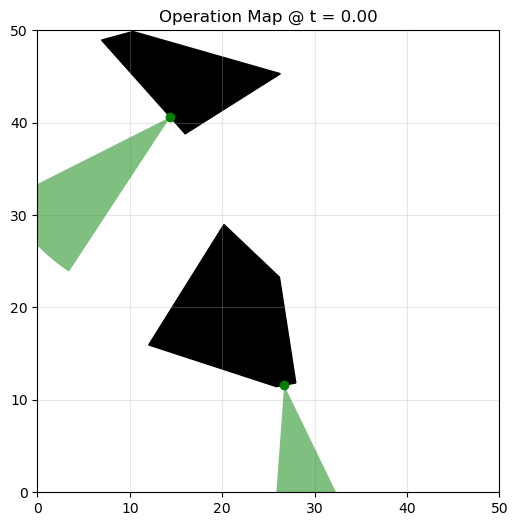

In [2]:
# Inputs (from files in /mnt/data provided by you):
#   - defender_info.json    :: initial camera specs (x,y, init_angle, bound, fov, ...)
#     (example: /mnt/data/defender_info.json). :contentReference[oaicite:3]{index=3}
#   - stp_rrt_result.json   :: initial attacker path waypoints (x,y,t). :contentReference[oaicite:4]{index=4}
#   - stp_rrt_setup.json    :: setup like x0/xf/vmax. :contentReference[oaicite:5]{index=5}
#
# Outputs:
#   - saves 'attacker_history.npy', 'defender_history.npy', 'objective_history.npy'
#   - prints iteration logs and shows final optimized variables.

# ---------------------------
# Construct d0
# ---------------------------
map_size = (50, 50)
num_buildings = 2
num_sensors = 2
fov_half_rad = np.deg2rad(15)
max_range = 20
panspeed_range = (np.deg2rad(-10), np.deg2rad(10))
cam_period = 200
cam_increment = 0.2
rng_seed = 6

# Run to Generate Map for Operation
map_in, cam_dict = generate_map(
    map_size = map_size,
    num_buildings = num_buildings,
    num_sensors = num_sensors,
    fov_half_rad = fov_half_rad,
    max_range = max_range,
    panspeed_range = panspeed_range,
    cam_period = cam_period,
    cam_increment = cam_increment,
    rng_seed = rng_seed,
    balanced_sensors = False     # spread sensors across buildings
)

visualize_map_at_time(map_in, cam_dict, t=0, sensor_alpha=0.5)

In [3]:
# ---------------------------
# Setup for STP-RRT*
# ---------------------------
x0 = [0, 0, 0]
xf = [map_size[0], map_size[1], 100]
vmax = 5

stp_rrt_setup = {}
stp_rrt_setup['x0'] = x0
stp_rrt_setup['xf'] = xf
stp_rrt_setup['vmax'] = vmax

# Output into JSON file
# Full path to the file
file_path1 = os.path.join("json/zero_sum_game", "operation_map.json")
file_path2 = os.path.join("json/zero_sum_game", "defender_info.json")
file_path3 = os.path.join("json/zero_sum_game", "stp_rrt_setup.json")

# Write JSON file into that folder
with open(file_path1, "w") as f:
    json.dump(make_json_serializable(map_in), f, indent=4)

with open(file_path2, "w") as f:
    json.dump(make_json_serializable(cam_dict), f, indent=4)

with open(file_path3, "w") as f:
    json.dump(stp_rrt_setup, f, indent=4)

Iteration: 0
Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41
Iteration: 42
Iteration: 43
Iteration: 44
Iteration: 45
Iteration: 46
Iteration: 47
Iteration: 48
Iteration: 49
Iteration: 50
Iteration: 51
Iteration: 52
Iteration: 53
Iteration: 54
Iteration: 55
Iteration: 56
Iteration: 57
Iteration: 58
Iteration: 59
Iteration: 60
Iteration: 61
Iteration: 62
Iteration: 63
Iteration: 64
Iteration: 65
Iteration: 66
Iteration: 67
Iteration: 68
Iteration: 69
Iteration: 70
Iteration: 71
It

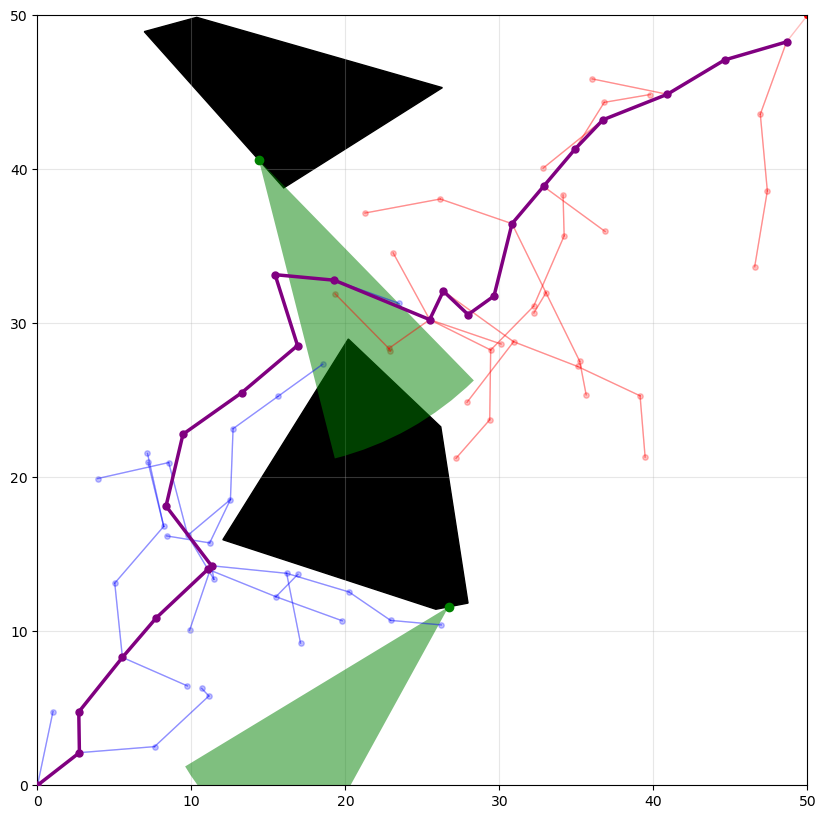

In [4]:
# ---------------------------
# Compute a0
# ---------------------------
%run ./stp_rrtstar.ipynb

# Import data
file_path_stp_rrtstar = os.path.join("json/zero_sum_game", "stp_rrt_result.json")
with open(file_path_stp_rrtstar, "r") as f:
    stp_rrtstar_result = json.load(f)

# Parse Data:
stp_rrtstar_path = stp_rrtstar_result['path']
stp_rrtstar_Va = stp_rrtstar_result['vertex']['start_tree']
stp_rrtstar_Ea = stp_rrtstar_result['edge']['start_tree']
stp_rrtstar_Vb = stp_rrtstar_result['vertex']['goal_tree']
stp_rrtstar_Eb = stp_rrtstar_result['edge']['goal_tree']
stp_rrtstar_computation_time = stp_rrtstar_result['computation_time']
stp_rrtstar_distance_cost = stp_rrtstar_result['distance_cost']
stp_rrtstar_time_cost = stp_rrtstar_result['time_cost']

In [5]:
# ---------------------------
# Helper I/O
# ---------------------------
DATA_DIR = "json/zero_sum_game"  # adjust if needed
DEFENDER_FILE = os.path.join(DATA_DIR, "defender_info.json")
PATH_FILE = os.path.join(DATA_DIR, "stp_rrt_result.json")
SETUP_FILE = os.path.join(DATA_DIR, "stp_rrt_setup.json")

with open(DEFENDER_FILE, "r") as f:
    cam_info = json.load(f)   # defender_info.json (initial camera positions + spec)
# cam_info fields: 'n', 'x'[], 'y'[], 'spec' {...}
# See uploaded file for exact format. :contentReference[oaicite:6]{index=6}

with open(PATH_FILE, "r") as f:
    rrt = json.load(f)        # stp_rrt_result.json (initial attacker waypoints)
# rrt['path'] is list of [x,y,t]. :contentReference[oaicite:7]{index=7}

with open(SETUP_FILE, "r") as f:
    setup = json.load(f)      # stp_rrt_setup.json (vmax, x0, xf)
# e.g., setup['vmax'] etc. :contentReference[oaicite:8]{index=8}

In [6]:
# ---------------------------
# Problem dimensions & parameters (tweakable)
# ---------------------------
ncam = int(cam_info.get("n", len(cam_info.get("x", []))))
assert ncam > 0
# Attacker waypoints: use the RRT path as initial a0
path0 = np.array(rrt["path"], dtype=float)   # shape (N,3): x,y,t
N = path0.shape[0]

vmax = float(setup.get("vmax", 5.0))
t0_fixed = float(path0[0, 2])
tN_fixed = float(path0[-1, 2])

# Sensor model parameters (smooth/differentiable)
s_max = 0.9        # maximum per-camera detection probability (scale)
r0 = 12.0          # half-range parameter (m); controls sigmoid center
r_scale = 2.0      # radial falloff scale for sigmoid

# Angular falloff: we use cosine of angle difference and clamp to positive part smoothly
eps_cos_smooth = 1e-3

# FOV half-angle from camera spec (assuming same for all in your JSON)
fov_half = float(cam_info["spec"]["fov"][0]) if "spec" in cam_info and "fov" in cam_info["spec"] else 0.45

# Defender variable bounds: we will treat defender decision as a per-camera *angle offset*
# delta_i ∈ [bound_minus, bound_plus] relative to init_angle (these bounds come from your JSON)
init_angles = np.array(cam_info["spec"]["init_angle"], dtype=float)  # length ncam
bounds_list = np.array(cam_info["spec"]["bound"], dtype=float)      # shape (ncam, 2) in your file [plus, minus]
# But your file used [ +, - ] ordering — we'll interpret as [plus, minus] so lower = -abs(neg), upper = +abs(pos)
cam_lower = np.array([bounds_list[i][1] for i in range(ncam)], dtype=float)  # bound minus
cam_upper = np.array([bounds_list[i][0] for i in range(ncam)], dtype=float)  # bound plus

In [7]:
# ---------------------------
# Utility: detection (numerical) - used for defender BR-gap estimate (numpy version)
# ---------------------------
def per_waypoint_detection_numpy(waypoints, cam_angles):
    # waypoints: (N,3) x,y,t
    # cam_angles: length ncam center angles (radians)
    # returns total detection scalar J = sum_i sum_cam k_{cam}(waypoint_i)
    total = 0.0
    for i in range(waypoints.shape[0]):
        px, py, _t = waypoints[i]
        for c in range(ncam):
            cx = float(cam_info["x"][c]); cy = float(cam_info["y"][c])
            dx = px - cx; dy = py - cy
            rng = math.hypot(dx, dy)
            # range component: sigmoid shaped (decreasing with rng)
            p_r = 1.0 / (1.0 + math.exp((rng - r0) / r_scale))
            # angle between camera center and vector to point
            ang_to_point = math.atan2(dy, dx)
            ang_diff = math.atan2(math.sin(ang_to_point - cam_angles[c]), math.cos(ang_to_point - cam_angles[c]))
            cosv = math.cos(ang_diff)
            # smooth positive part approx
            pos_cos = 0.5 * (cosv + math.sqrt(cosv * cosv + eps_cos_smooth))
            p_ang = pos_cos  # in [0,1]
            k = s_max * p_r * p_ang
            total += k
    return float(total)

In [8]:
import numpy as np
import casadi as ca

# ---------------------------
# CasADi builder for attacker NLP (log-sum objective)
# Decision vars: X = [x1..xN,y1..yN], T = [t1..tN] (t1 and tN fixed)
# Objective: MAX sum_i log(1 - k(x_i, t_i))  -  λ * (T_N - T_1)
# Constraints: speed <= vmax, monotonic time, bbox bounds
# ---------------------------
def build_attacker_nlp(
    cam_angles,              # np.ndarray shape (ncam,) -> fixed defender headings (rad) OR a scalar per-cam if time-invariant
    cam_info,                # dict with keys: "x", "y", and either "fov_ang" (scalar or list per cam)
    path0,                   # np.ndarray (M,3): seed [x,y,t]
    map_bounds=[0, map_size[0],0, map_size[1]],         # [xmin, xmax, ymin, ymax] or None -> derive from path0 with margin
    k_steepness=100.0,       # angular sigmoid sharpness (k)
    time_penalty_coef=0.02,  # λ in λ * (T_N - T_1)
    N=None,                  # number of nodes; default len(path0)
    warm_init=None           # {'xy': (N,2), 't': (N,)} optional
):
    """
    Returns:
        opti, X, T, info
        - opti: CasADi Opti
        - X: (N,2) decision variable
        - T: (N,1) decision variable (timestamps)
        - info: dict with utility evaluators: {'log_sum_fun': ..., 'penalty_fun': ..., 'alpha': float}
    """
    # --- resolve sizes & defaults ---
    path0 = np.asarray(path0, dtype=float)
    if path0.ndim != 2 or path0.shape[1] != 3:
        raise ValueError("path0 must be shape (M,3) with columns [x,y,t].")
    if N is None:
        N = path0.shape[0]
    if N < 2:
        raise ValueError("N must be >= 2")

    ncam = int(len(cam_angles))
    cam_angles = np.asarray(cam_angles, dtype=float)

    # fov_ang may be scalar or per-camera list/array
    fov_ang = cam_info.get("fov_ang", np.deg2rad(90.0))
    if np.isscalar(fov_ang):
        fov_ang = np.full(ncam, float(fov_ang), dtype=float)
    else:
        fov_ang = np.asarray(fov_ang, dtype=float)
        if fov_ang.shape[0] != ncam:
            raise ValueError("cam_info['fov_ang'] length must match ncam.")

    # vmax and bbox
    xs, ys = path0[:,0], path0[:,1]
    if map_bounds is None:
        margin = 1.0
        xmin, xmax = float(xs.min()-margin), float(xs.max()+margin)
        ymin, ymax = float(ys.min()-margin), float(ys.max()+margin)
    else:
        xmin, xmax, ymin, ymax = map_bounds

    # If path0 length != N, resample (linear in index; times linear too)
    if path0.shape[0] != N:
        idx = np.linspace(0, path0.shape[0]-1, N)
        x_seed = np.interp(idx, np.arange(path0.shape[0]), path0[:,0])
        y_seed = np.interp(idx, np.arange(path0.shape[0]), path0[:,1])
        t_seed = np.interp(idx, np.arange(path0.shape[0]), path0[:,2])
        pathN = np.column_stack([x_seed, y_seed, t_seed])
    else:
        pathN = path0.copy()

    t1_fix = float(pathN[0,2])
    tN_fix = float(pathN[-1,2])

    # constants for k(x,t)
    alpha = 99.0 / (float(max_range)**2)  # distance decay
    k_sig = float(k_steepness)
    eps_log = 1e-9                       # for log(1 - k) safety
    k_max = 1.0 - 1e-9                   # clamp ceiling

    # --- build Opti ---
    opti = ca.Opti()
    X = opti.variable(N, 2)  # [x,y]
    T = opti.variable(N, 1)  # times

    # --- objective: sum_i log(1 - k(x_i, t_i)) - λ*(T_N - T_1)
    log_sum = 0
    for i in range(N):
        px = X[i,0]; py = X[i,1]
        ti = T[i,0]

        k_node = 0
        for c in range(ncam):
            cx = float(cam_info["x"][c]); cy = float(cam_info["y"][c])
            phi = cam_angles[c]                  # defender heading fixed for this subproblem
            theta = fov_ang[c]                   # FOV width (rad)

            dx = px - cx
            dy = py - cy
            dist2 = dx*dx + dy*dy
            dist = ca.sqrt(dist2 + 1e-12)

            # projection along boresight
            cos_alpha = (dx * ca.cos(phi) + dy * ca.sin(phi)) / dist

            # visibility: inside-cone sigmoid (original form)
            vis = 1.0 / (1.0 + ca.exp(-k_sig * (cos_alpha - ca.cos(theta/2.0))))
            # range decay
            obs = 1.0 / (1.0 + alpha * dist2)

            k_node = k_node + vis * obs

        # clamp for numerical safety so (1 - k) stays positive
        k_node = ca.fmin(ca.fmax(k_node, 0.0), k_max)

        # accumulate log(1 - k)
        log_sum = log_sum + ca.log(ca.fmax(1.0 - k_node, eps_log))

    # time penalty on total duration (encourages shorter paths)
    total_duration = T[-1,0] - T[0,0]
    J_total = log_sum - time_penalty_coef * total_duration

    # Maximize J_total  <=> minimize -J_total
    opti.minimize(-J_total)

    # --- constraints ---
    # fixed endpoints (times)
    opti.subject_to(T[0,0] == t1_fix)
    opti.subject_to(T[-1,0] == tN_fix)

    opti.subject_to(X[0, 0] == float(x0[0]))
    opti.subject_to(X[0, 1] == float(x0[1]))
    # enforce last row
    opti.subject_to(X[-1, 0] == float(xf[0]))
    opti.subject_to(X[-1, 1] == float(xf[1]))

    # monotonic time & speed constraint
    for i in range(N-1):
        dt = T[i+1,0] - T[i,0]
        opti.subject_to(dt >= 1e-3)
        dx = X[i+1,0] - X[i,0]
        dy = X[i+1,1] - X[i,1]
        dist = ca.sqrt(dx*dx + dy*dy + 1e-12)
        opti.subject_to(dist <= vmax * dt)

    # bbox
    opti.subject_to(opti.bounded(xmin, X[:,0], xmax))
    opti.subject_to(opti.bounded(ymin, X[:,1], ymax))

    # --- warm start / initials ---
    if warm_init is not None and ("xy" in warm_init) and ("t" in warm_init):
        opti.set_initial(X, warm_init["xy"])
        opti.set_initial(T, warm_init["t"].reshape((N,1)))
    else:
        opti.set_initial(X, pathN[:,0:2])
        opti.set_initial(T, pathN[:,2].reshape((N,1)))

    # --- utility evaluators (optional, for diagnostics like your script) ---
    w_sym = ca.vertcat(X.reshape((-1,1)), T.reshape((-1,1)))
    log_sum_fun = ca.Function('log_sum_eval', [w_sym], [log_sum])
    penalty_fun = ca.Function('penalty_eval', [w_sym], [time_penalty_coef * total_duration])

    # solver
    p_opts = {"expand": True}
    s_opts = {"max_iter": 3000, "tol": 1e-6, "acceptable_tol": 1e-4, "print_level": 0}
    opti.solver("ipopt", p_opts, s_opts)

    info = {"log_sum_fun": log_sum_fun, "penalty_fun": penalty_fun, "alpha": alpha}
    return opti, X, T, info


In [9]:
# Building param:
alpha_vec = []
building_edge_vec = []
building_vector_vec = []

# Find edge of convex polygon with camera:
def closest_edge(building, cam_xy, tol=None):
    P = np.asarray(building, dtype=float)
    x = np.asarray(cam_xy, dtype=float)
    M = P.shape[0]
    assert M >= 3

    Pn = np.vstack([P, P[0]])
    Ls = np.linalg.norm(Pn[1:] - Pn[:-1], axis=1)
    Lmean = float(np.mean(Ls))
    if tol is None:
        tol = 1e-3 * Lmean if Lmean > 0 else 1e-6

    best = None
    for i in range(M):
        p0_i, p1_i = Pn[i], Pn[i+1]
        v_i = p1_i - p0_i
        L2 = float(v_i @ v_i)
        if L2 < 1e-16:
            continue
        t_raw = float((x - p0_i) @ v_i / L2)
        t_clamped = min(1.0, max(0.0, t_raw))
        proj_i = p0_i + t_clamped * v_i
        d2_i = float(np.sum((x - proj_i)**2))
        if (best is None) or (d2_i < best["d2"]):
            L = np.sqrt(L2)
            t_hat = v_i / L
            n_hat = np.array([-t_hat[1], t_hat[0]])
            best = dict(
                edge_idx=i, alpha=t_clamped, proj=proj_i, d2=d2_i,
                tangent=t_hat, normal=n_hat, p0=p0_i, p1=p1_i
            )

    dist = float(np.sqrt(best["d2"])) if best is not None else np.inf
    is_on = bool(dist <= tol)

    vertex_hit = None
    vdist = np.linalg.norm(P - x, axis=1)
    v_idx = int(np.argmin(vdist))
    if float(vdist[v_idx]) <= tol:
        vertex_hit = v_idx

    # *** CRITICAL: compute v_e from best['p1'] and best['p0'], not loop vars ***
    v_e = best["p1"] - best["p0"]

    best.update({
        "is_on_building": is_on,
        "distance": dist,
        "vertex_hit": vertex_hit,
        "tol_used": float(tol),
        "v_e": v_e
    })
    return best

for n_building in range(map_in['st']['n']):
    for n_sensor in range(cam_dict['n']):
        pos_sensor_j = closest_edge(map_in['st'][str(n_building)], [cam_dict['x'][n_sensor], cam_dict['y'][n_sensor]])
        
        if pos_sensor_j['is_on_building']:
            alpha_vec.append(pos_sensor_j['alpha'])
            building_edge_vec.append(pos_sensor_j['p0'])
            building_vector_vec.append(pos_sensor_j['v_e'])

E0 = np.array(building_edge_vec, dtype=float)    # (m, 2)
V  = np.array(building_vector_vec,  dtype=float)    # (m, 2)
m  = cam_dict['n']

def build_defender_nlp(A_mat, P_fun, alpha0=None):
    """
    Maximize detection J(A, S(alpha)) with alpha in [0,1]^m,
    where S(alpha)_i = E0_i + alpha_i * v_i
    """
    opti = ca.Opti()

    # Decision: alpha ∈ [0,1]^m
    alpha = opti.variable(m, 1)

    # Construct S(alpha) symbolically: 2 x m (rows: x, y)
    x_sym = []
    y_sym = []
    for i in range(m):
        x_i = E0[i,0] + alpha[i,0]*V[i,0]
        y_i = E0[i,1] + alpha[i,0]*V[i,1]
        x_sym.append(x_i)
        y_sym.append(y_i)
    S_sym = ca.vertcat(ca.hcat([x for x in x_sym]),
                       ca.hcat([y for y in y_sym]))  # 2 x m

    # Objective: maximize J(A,S) -> minimize -J
    # P_fun should return a scalar; if it returns a dict, access the 'cost' (or adapt accordingly)
    P_out = P_fun(A=A_mat, S=S_sym)
    J = P_out['cost'] if isinstance(P_out, dict) else P_out[0]
    opti.minimize(-J)

    # Bounds: alpha ∈ [0,1]
    opti.subject_to(opti.bounded(0.0, alpha, 1.0))

    # Warm start
    if alpha0 is None:
        alpha0 = 0.5*np.ones((m,1))
    opti.set_initial(alpha, alpha0)

    # Solve
    p_opts = {"expand": True}
    s_opts = {"max_iter": 2000, "tol": 1e-6, "acceptable_tol": 1e-4, "print_level": 0}
    opti.solver("ipopt", p_opts, s_opts)
    sol = opti.solve()

    alpha_opt = np.array(sol.value(alpha)).reshape(m,1)
    x_opt = E0[:,0] + alpha_opt[:,0]*V[:,0]
    y_opt = E0[:,1] + alpha_opt[:,0]*V[:,1]
    S_opt = np.vstack([x_opt, y_opt])

    # Evaluate optimum J
    P_eval = P_fun(A=A_mat, S=ca.DM(S_opt))
    J_opt = float(P_eval['cost'] if isinstance(P_eval, dict) else P_eval[0])

    return {"alpha_opt": alpha_opt, "S_opt": S_opt, "J_opt": J_opt}

In [10]:
def build_casadi_P(n, m, beta=0.3):
    """
    Input:
    n: number of vertices in STP-RRT*
    m: number of sensors
    beta: decay constant

    Output:
    Cost function J, Jacobian dJdA (attacker waypoints), dJdS (sensor mount)
    """
    # Casadi Symbolic
    A = ca.MX.sym('A', 3, n)    # rows: x, y, t
    S = ca.MX.sym('S', 2, m)    # rows: px, py

    xs = A[0, :]
    ys = A[1, :]
    ts = A[2, :]

    pxs = S[0, :]
    pys = S[1, :]

    # compute PoD of kth vertex from jth sensor
    P_detect = ca.MX.zeros(m, n)
    for j in range(m):
        dx = xs - pxs[j]
        dy = ys - pys[j]
        r = ca.sqrt(dx**2 + dy**2 + 1e-12)
        P_detect[j, :] = ca.exp(-beta * r)

    # Combine per stage
    p_k = ca.MX.zeros(n, 1)
    for k in range(n):
        prod = ca.MX(1.0)
        for j in range(m):
            prod = prod*(1 - P_detect[j, k])
        p_k[k] = 1 - prod

    # Time weights (w_k)
    # TODO: good way to assign weights?
    w = ca.MX.ones(n, 1)

    cost = ca.sum1(ca.mtimes(w.T, p_k))

    # Find Jacobians
    dJdA = ca.jacobian(cost, A)
    dJdS = ca.jacobian(cost, S)

    P_func = ca.Function('P_casadi', [A, S], [cost, dJdA, dJdS], ['A', 'S'], ['cost', 'dJdA', 'dJdS'])
    return P_func

In [ ]:
# ---------------------------
# Alternation loop
# ---------------------------
max_alt_iters = 100
tol_var = 1e-3
tol_br_gap = 1e-3

# initial states (a0, d0)
a_current = deepcopy(path0)          # (N,3)
N = a_current.shape[0]

# defender param is now "alpha" along edges, not angle delta.
# use alpha_vec from the building-edge preprocessing if available,
# otherwise start from zeros.
if "alpha_vec" in globals() and len(alpha_vec) == m:
    d_current_delta = np.array(alpha_vec, dtype=float).reshape((m,))
else:
    d_current_delta = np.zeros(m, dtype=float)

attacker_history = []
defender_history = []
objective_history = []

print("Starting alternating best-response loop")
start_time_total = time.time()
# Build CasADi-based detection probability cost function
P_fun = build_casadi_P(
    n=len(path0),              # number of waypoints in initial STP-RRT* path
    m=cam_info['n'],        # or len(cam_info['x']) if not stored explicitly
    beta=0.3                   # decay constant as used in zero_sum_game_casadi
)

for k in range(max_alt_iters):
    iter_start = time.time()
    print(f"\n=== Iter {k+1}: Defender solve (given attacker) ===")

    # Build attacker trajectory matrix A for the current path
    A_mat = ca.DM(
        np.vstack([
            a_current[:, 0],  # x
            a_current[:, 1],  # y
            a_current[:, 2],  # t
        ])
    )

    # J(a, d_old) for BR-gap / diagnostics
    x_prev = E0[:, 0] + d_current_delta * V[:, 0]
    y_prev = E0[:, 1] + d_current_delta * V[:, 1]
    S_prev = ca.DM(np.vstack([x_prev, y_prev]))
    P_prev = P_fun(A=A_mat, S=S_prev)
    J_prev_def = float(P_prev["cost"] if isinstance(P_prev, dict) else P_prev[0])

    # -----------------------
    # 1) Defender best response around current attacker a_current
    # -----------------------
    try:
        # new API: build_defender_nlp(A_mat, P_fun, alpha0)
        def_res = build_defender_nlp(A_mat=A_mat, P_fun=P_fun, alpha0=d_current_delta)
        d_new_delta = np.array(def_res["alpha_opt"]).reshape((m,))
        J_after_def = float(def_res["J_opt"])
    except Exception as e:
        print("Defender NLP failed:", e)
        d_new_delta = d_current_delta.copy()
        # fall back: keep previous objective
        J_after_def = J_prev_def

    # update defender state
    delta_d = np.linalg.norm(d_new_delta - d_current_delta) / (np.linalg.norm(d_current_delta) + 1e-8)
    d_current_delta = d_new_delta.copy()
    defender_history.append(d_current_delta.copy())

    # reconstruct S(alpha) for this defender strategy
    x_s = E0[:, 0] + d_current_delta * V[:, 0]
    y_s = E0[:, 1] + d_current_delta * V[:, 1]
    S_current = np.vstack([x_s, y_s])

    print(f" Defender J(a, d_new) = {J_after_def:.6f}, ||Δalpha||_rel = {delta_d:.4e}")

    # -----------------------
    # 2) Attacker best response around new defender (positions in S_current)
    # -----------------------
    print(f"=== Iter {k+1}: Attacker solve (given defender) ===")

    # copy cam_info and overwrite x,y with the updated S
    cam_info_iter = dict(cam_info)
    cam_info_iter["x"] = S_current[0, :].tolist()
    cam_info_iter["y"] = S_current[1, :].tolist()

    # defender headings for attacker model: keep init_angles for now
    cam_angles_fixed = init_angles

    # use current attacker path as warm start
    warm_init = {"xy": a_current[:, 0:2], "t": a_current[:, 2]}

    opti_a, X_var, T_var, info_a = build_attacker_nlp(
        cam_angles=cam_angles_fixed,
        cam_info=cam_info_iter,
        path0=a_current,
        N=N,
        warm_init=warm_init,
        # map_bounds can be left to its default [0, map_size[0], 0, map_size[1]]
    )

    try:
        sol_a = opti_a.solve()
        X_sol = np.array(sol_a.value(X_var))
        T_sol = np.array(sol_a.value(T_var)).reshape((N,))
        a_new = np.hstack([X_sol, T_sol.reshape((N, 1))])
    except Exception as e:
        print("Attacker NLP failed:", e)
        a_new = a_current.copy()

    # evaluate J(a_new, d_current) via the same CasADi cost P_fun
    A_mat_new = ca.DM(
        np.vstack([
            a_new[:, 0],
            a_new[:, 1],
            a_new[:, 2],
        ])
    )
    P_att = P_fun(A=A_mat_new, S=ca.DM(S_current))
    J_after_att = float(P_att["cost"] if isinstance(P_att, dict) else P_att[0])

    delta_a = np.linalg.norm(a_new - a_current) / (np.linalg.norm(a_current) + 1e-8)
    print(f" Attacker J(a_new, d) = {J_after_att:.6f}, ||Δa||_rel = {delta_a:.4e}")

    a_current = a_new.copy()
    attacker_history.append(a_current.copy())

    # Store objectives (defender after-update, attacker after-update)
    objective_history.append((float(J_after_def), float(J_after_att)))

    # -----------------------
    # 3) Best-response gap proxy (how much defender improved this iter)
    # -----------------------
    br_gap = J_after_def - J_prev_def
    print(f" BR-gap proxy (J_def_new - J_def_old) = {br_gap:.6e}")

    # -----------------------
    # 4) Stopping criteria
    # -----------------------
    max_change = max(delta_d, delta_a, abs(br_gap))
    iter_time = time.time() - iter_start
    print(f" Iter {k+1} done — iter_time = {iter_time:.2f}s, max_change = {max_change:.4e}")

    # if (max_change < tol_var) or (abs(br_gap) < tol_br_gap):
    #     print("Convergence/stopping criteria met. Breaking loop.")
    #     break

    # -----------------------
    # 5) Update
    # -----------------------
    P_fun = build_casadi_P(
        n=len(a_current),              # number of waypoints in initial STP-RRT* path
        m=cam_info['n'],        # or len(cam_info['x']) if not stored explicitly
        beta=0.3                   # decay constant as used in zero_sum_game_casadi
    )

end_total = time.time() - start_time_total
print(f"\nAlternation finished in {end_total:.2f}s after {k+1} iterations.")
print("Saving attacker_history.npy, defender_history.npy, objective_history.npy in", DATA_DIR)

# -----------------------
# Save results
# -----------------------
np.save(os.path.join(DATA_DIR, "attacker_history.npy"), np.array(attacker_history))
np.save(os.path.join(DATA_DIR, "defender_history.npy"), np.array(defender_history))
np.save(os.path.join(DATA_DIR, "objective_history.npy"), np.array(objective_history))

# Print final found solutions
final_cam_angles = init_angles  # orientation kept fixed in this variant
print("\nFinal defender alphas (along edges):", d_current_delta)
print("Final cam center angles (rad):", final_cam_angles)
print("Final attacker path (first & last 3 waypoints):")
np.set_printoptions(precision=4, suppress=True)
print(a_current[:3])
print("...")
print(a_current[-3:])


Starting alternating best-response loop

=== Iter 1: Defender solve (given attacker) ===

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  | 388.00us ( 64.67us)  25.30us (  4.22us)         6
       nlp_g  | 225.00us ( 37.50us)  13.47us (  2.25us)         6
  nlp_grad_f  | 603.00us ( 86.14us)  39.79us (  5.68us)         7
  nlp_hess_l  | 636.00us (127.20us)  42.29us (  8.46us)         5
   nlp_jac_g  | 188.00us ( 26.86us)  12.03us (  1.72us)         7
       total  |  54.33ms ( 54.33ms)   3.63ms (  3.63ms)         1
 Defender J(a, d_new) = 0.530560, ||Δalpha||_rel = 4.7560e-01
